In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [2]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

X = rng.random((100, 1)) - 0.5

y = 3 * X[:, 0]**2 + 0.05 * rng.normal(size=100)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (100, 1)
y shape: (100,)


In [3]:
df = pd.DataFrame({
    "X": X[:, 0],
    "y": y
})

df.head(10)

,X,y
0,0.2740,0.2451
1,-0.0611,-0.0341
2,0.3586,0.3669
3,0.1974,0.1818
4,-0.4058,0.4763
5,0.4756,0.7155
6,0.2611,0.1579
7,0.2861,0.2352
8,-0.3719,0.3674
9,-0.0496,-0.0096


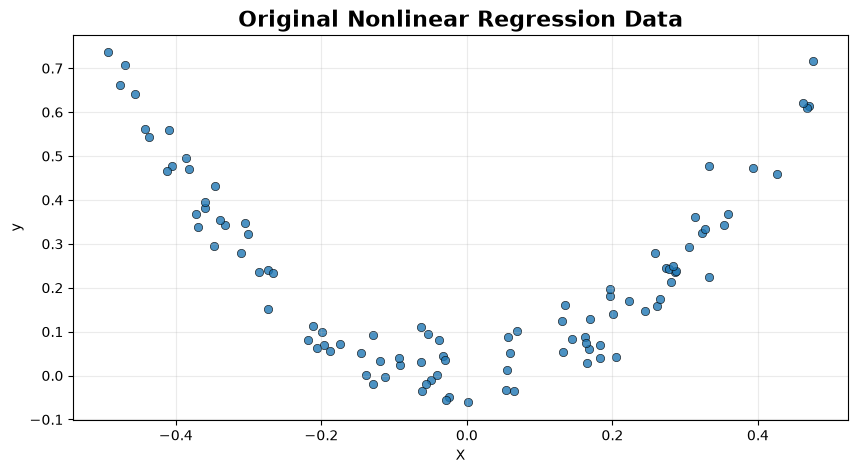

In [4]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["X"],
    df["y"],
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Original Nonlinear Regression Data", fontsize=16, fontweight="bold")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha=0.25)
plt.show()

In [5]:
initial_prediction = y.mean()

df["pred_0"] = initial_prediction

print(f"Initial prediction (mean of y): {initial_prediction:.6f}")
df.head()

Initial prediction (mean of y): 0.222186


,X,y,pred_0
0,0.2740,0.2451,0.2222
1,-0.0611,-0.0341,0.2222
2,0.3586,0.3669,0.2222
3,0.1974,0.1818,0.2222
4,-0.4058,0.4763,0.2222


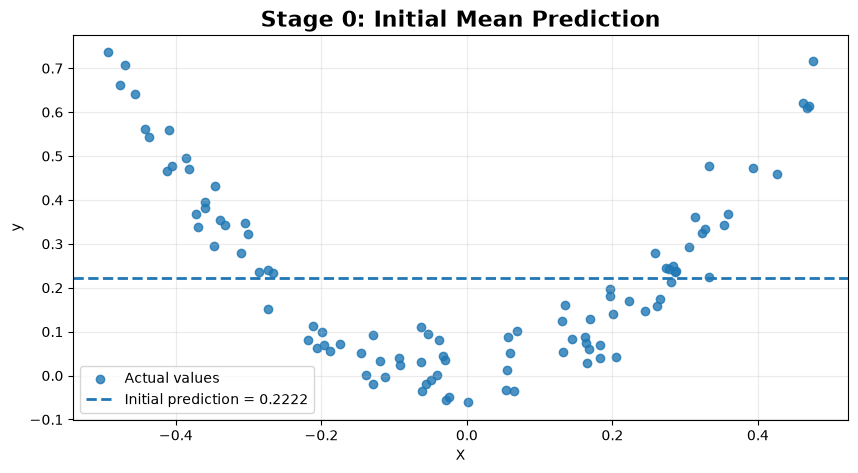

In [6]:
plt.figure(figsize=(10, 5))

plt.scatter(df["X"], df["y"], alpha=0.8, label="Actual values")
plt.axhline(
    initial_prediction,
    linestyle="--",
    linewidth=2,
    label=f"Initial prediction = {initial_prediction:.4f}"
)

plt.title("Stage 0: Initial Mean Prediction", fontsize=16, fontweight="bold")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [7]:
df["residual_0"] = df["y"] - df["pred_0"]

df[["X", "y", "pred_0", "residual_0"]].head(10)

,X,y,pred_0,residual_0
0,0.2740,0.2451,0.2222,0.0230
1,-0.0611,-0.0341,0.2222,-0.2563
2,0.3586,0.3669,0.2222,0.1447
3,0.1974,0.1818,0.2222,-0.0404
4,-0.4058,0.4763,0.2222,0.2541
5,0.4756,0.7155,0.2222,0.4933
6,0.2611,0.1579,0.2222,-0.0643
7,0.2861,0.2352,0.2222,0.0130
8,-0.3719,0.3674,0.2222,0.1452
9,-0.0496,-0.0096,0.2222,-0.2318


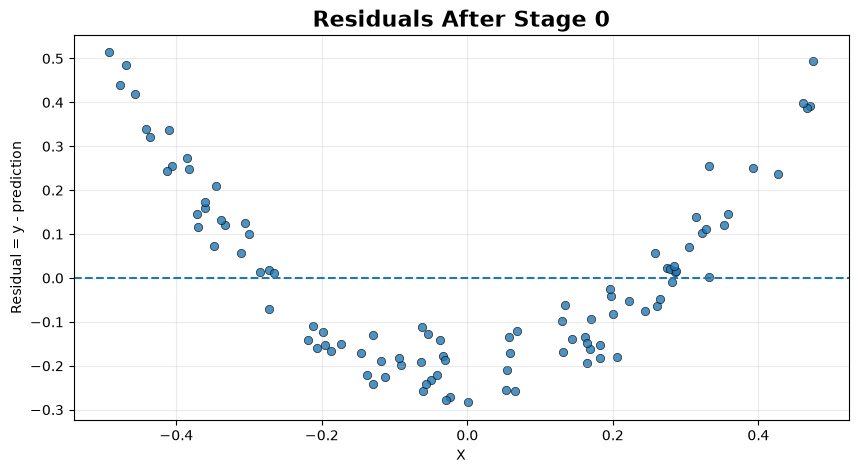

In [8]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["X"],
    df["residual_0"],
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5
)
plt.axhline(0, linestyle="--", linewidth=1.5)

plt.title("Residuals After Stage 0", fontsize=16, fontweight="bold")
plt.xlabel("X")
plt.ylabel("Residual = y - prediction")
plt.grid(alpha=0.25)
plt.show()

In [9]:
tree_1 = DecisionTreeRegressor(
    max_leaf_nodes=8,
    random_state=RANDOM_STATE
)

tree_1.fit(X, df["residual_0"])

tree_1_prediction = tree_1.predict(X)

df["tree_1_correction"] = tree_1_prediction

print("First residual tree trained successfully ✅")

First residual tree trained successfully ✅


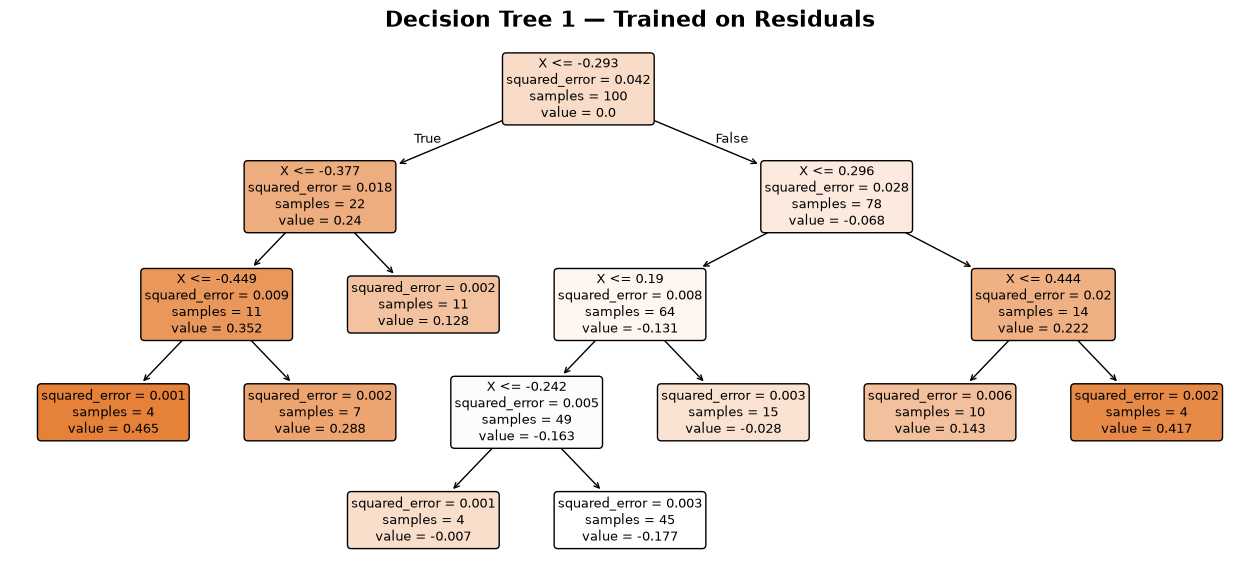

In [10]:
plt.figure(figsize=(16, 7))

plot_tree(
    tree_1,
    feature_names=["X"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree 1 — Trained on Residuals", fontsize=16, fontweight="bold")
plt.show()

In [11]:
learning_rate = 1.0

df["pred_1"] = (
    df["pred_0"]
    + learning_rate * df["tree_1_correction"]
)

df["residual_1"] = df["y"] - df["pred_1"]

df[[
    "X",
    "y",
    "pred_0",
    "tree_1_correction",
    "pred_1",
    "residual_1"
]].head(10)

,X,y,pred_0,tree_1_correction,pred_1,residual_1
0,0.2740,0.2451,0.2222,-0.0276,0.1945,0.0506
1,-0.0611,-0.0341,0.2222,-0.1766,0.0455,-0.0796
2,0.3586,0.3669,0.2222,0.1433,0.3655,0.0014
3,0.1974,0.1818,0.2222,-0.0276,0.1945,-0.0127
4,-0.4058,0.4763,0.2222,0.2882,0.5104,-0.0341
5,0.4756,0.7155,0.2222,0.4175,0.6397,0.0758
6,0.2611,0.1579,0.2222,-0.0276,0.1945,-0.0366
7,0.2861,0.2352,0.2222,-0.0276,0.1945,0.0407
8,-0.3719,0.3674,0.2222,0.1283,0.3505,0.0169
9,-0.0496,-0.0096,0.2222,-0.1766,0.0455,-0.0551


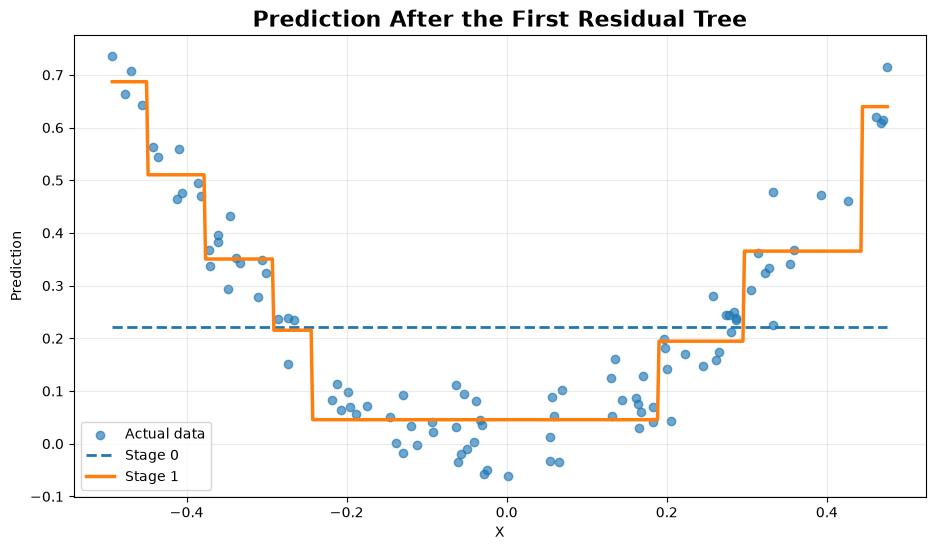

In [12]:
X_test = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

pred_stage_0 = np.full(X_test.shape[0], initial_prediction)

pred_stage_1 = (
    initial_prediction
    + learning_rate * tree_1.predict(X_test)
)

plt.figure(figsize=(11, 6))

plt.scatter(X[:, 0], y, alpha=0.65, label="Actual data")
plt.plot(X_test[:, 0], pred_stage_0, linestyle="--", linewidth=2, label="Stage 0")
plt.plot(X_test[:, 0], pred_stage_1, linewidth=2.5, label="Stage 1")

plt.title("Prediction After the First Residual Tree", fontsize=16, fontweight="bold")
plt.xlabel("X")
plt.ylabel("Prediction")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [13]:
tree_2 = DecisionTreeRegressor(
    max_leaf_nodes=8,
    random_state=RANDOM_STATE
)

tree_2.fit(X, df["residual_1"])

tree_2_prediction = tree_2.predict(X)

df["tree_2_correction"] = tree_2_prediction

df["pred_2"] = (
    df["pred_1"]
    + learning_rate * df["tree_2_correction"]
)

df["residual_2"] = df["y"] - df["pred_2"]

df[[
    "X",
    "y",
    "pred_1",
    "tree_2_correction",
    "pred_2",
    "residual_2"
]].head(10)


,X,y,pred_1,tree_2_correction,pred_2,residual_2
0,0.2740,0.2451,0.1945,-0.0078,0.1868,0.0584
1,-0.0611,-0.0341,0.0455,-0.0005,0.0451,-0.0792
2,0.3586,0.3669,0.3655,0.0583,0.4238,-0.0570
3,0.1974,0.1818,0.1945,-0.0078,0.1868,-0.0050
4,-0.4058,0.4763,0.5104,-0.0005,0.5099,-0.0337
5,0.4756,0.7155,0.6397,0.0758,0.7155,0.0000
6,0.2611,0.1579,0.1945,-0.0078,0.1868,-0.0289
7,0.2861,0.2352,0.1945,-0.0078,0.1868,0.0484
8,-0.3719,0.3674,0.3505,-0.0005,0.3500,0.0174
9,-0.0496,-0.0096,0.0455,-0.0005,0.0451,-0.0547


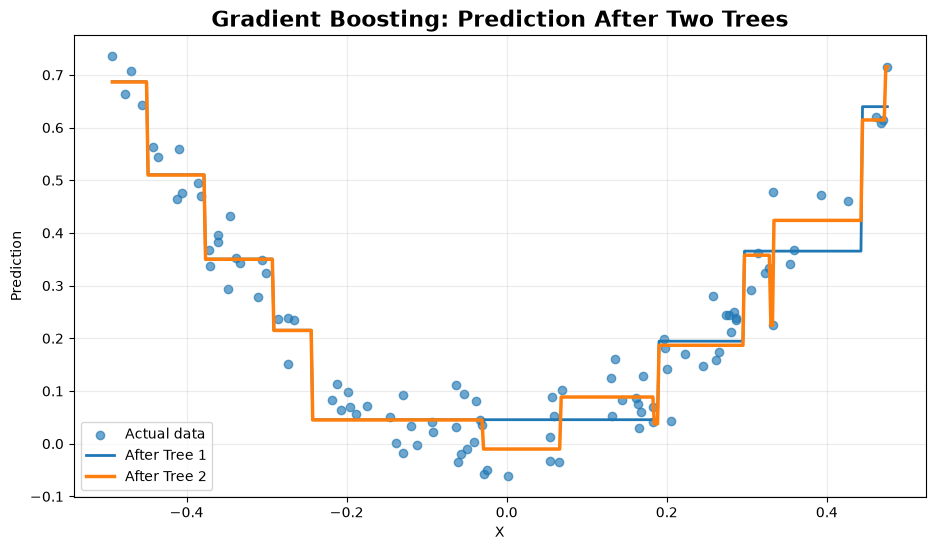

In [14]:
pred_stage_2 = (
    initial_prediction
    + learning_rate * tree_1.predict(X_test)
    + learning_rate * tree_2.predict(X_test)
)

plt.figure(figsize=(11, 6))

plt.scatter(X[:, 0], y, alpha=0.65, label="Actual data")
plt.plot(X_test[:, 0], pred_stage_1, linewidth=2, label="After Tree 1")
plt.plot(X_test[:, 0], pred_stage_2, linewidth=2.5, label="After Tree 2")

plt.title("Gradient Boosting: Prediction After Two Trees", fontsize=16, fontweight="bold")
plt.xlabel("X")
plt.ylabel("Prediction")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [15]:
def manual_gradient_boost(
    X,
    y,
    n_estimators=5,
    learning_rate=0.1,
    max_leaf_nodes=8,
    random_state=42
):

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    initial_prediction = y.mean()
    current_prediction = np.full_like(y, initial_prediction, dtype=float)

    trees = []
    train_history = []

    for stage in range(1, n_estimators + 1):
        residual = y - current_prediction

        tree = DecisionTreeRegressor(
            max_leaf_nodes=max_leaf_nodes,
            random_state=random_state + stage
        )
        tree.fit(X, residual)

        correction = tree.predict(X)
        current_prediction += learning_rate * correction

        trees.append(tree)

        train_rmse = np.sqrt(mean_squared_error(y, current_prediction))

        train_history.append({
            "stage": stage,
            "rmse": train_rmse,
            "mean_abs_residual": np.mean(np.abs(y - current_prediction))
        })

    return {
        "initial_prediction": initial_prediction,
        "trees": trees,
        "history": pd.DataFrame(train_history),
    }

def manual_predict(model, X_new, learning_rate=0.1):

    X_new = np.asarray(X_new)

    prediction = np.full(
        X_new.shape[0],
        model["initial_prediction"],
        dtype=float
    )

    for tree in model["trees"]:
        prediction += learning_rate * tree.predict(X_new)

    return prediction

In [16]:
manual_model = manual_gradient_boost(
    X,
    y,
    n_estimators=5,
    learning_rate=0.1,
    max_leaf_nodes=8,
    random_state=RANDOM_STATE
)

manual_model["history"]

,stage,rmse,mean_abs_residual
0,1,0.1866,0.1557
1,2,0.1697,0.1413
2,3,0.1545,0.1279
3,4,0.1408,0.1157
4,5,0.1285,0.1052


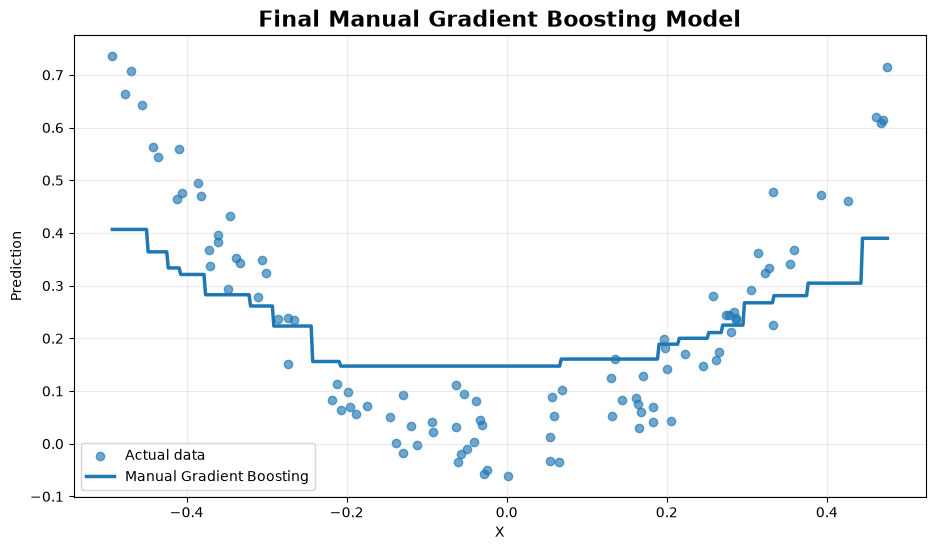

In [17]:
manual_train_pred = manual_predict(
    manual_model,
    X,
    learning_rate=0.1
)

manual_test_curve = manual_predict(
    manual_model,
    X_test,
    learning_rate=0.1
)

plt.figure(figsize=(11, 6))

plt.scatter(X[:, 0], y, alpha=0.65, label="Actual data")
plt.plot(
    X_test[:, 0],
    manual_test_curve,
    linewidth=2.5,
    label="Manual Gradient Boosting"
)

plt.title("Final Manual Gradient Boosting Model", fontsize=16, fontweight="bold")
plt.xlabel("X")
plt.ylabel("Prediction")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


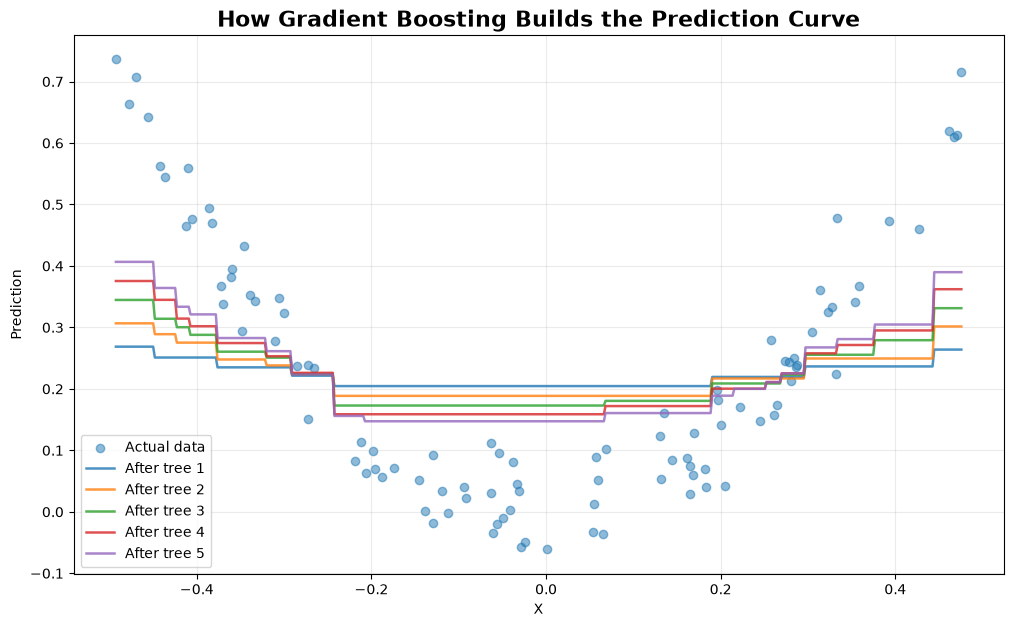

In [18]:
initial = manual_model["initial_prediction"]
stage_prediction = np.full(X_test.shape[0], initial, dtype=float)

plt.figure(figsize=(12, 7))

plt.scatter(
    X[:, 0],
    y,
    alpha=0.5,
    label="Actual data"
)

for stage, tree in enumerate(manual_model["trees"], start=1):
    stage_prediction += 0.1 * tree.predict(X_test)
    plt.plot(
        X_test[:, 0],
        stage_prediction,
        linewidth=1.8,
        alpha=0.8,
        label=f"After tree {stage}"
    )

plt.title("How Gradient Boosting Builds the Prediction Curve", fontsize=16, fontweight="bold")
plt.xlabel("X")
plt.ylabel("Prediction")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [19]:
def regression_report(y_true, y_pred):

    return pd.DataFrame({
        "Metric": [
            "Mean Absolute Error (MAE)",
            "Mean Squared Error (MSE)",
            "Root Mean Squared Error (RMSE)",
            "R² Score"
        ],
        "Value": [
            mean_absolute_error(y_true, y_pred),
            mean_squared_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
            r2_score(y_true, y_pred)
        ]
    })

manual_report = regression_report(y, manual_train_pred)
manual_report

,Metric,Value
0,Mean Absolute Error (MAE),0.1052
1,Mean Squared Error (MSE),0.0165
2,Root Mean Squared Error (RMSE),0.1285
3,R² Score,0.6099


In [20]:
sklearn_model = GradientBoostingRegressor(
    n_estimators=5,
    learning_rate=0.1,
    max_leaf_nodes=8,
    random_state=RANDOM_STATE
)

sklearn_model.fit(X, y)

sklearn_train_pred = sklearn_model.predict(X)
sklearn_curve = sklearn_model.predict(X_test)

print("Scikit-learn Gradient Boosting model trained successfully ✅")

Scikit-learn Gradient Boosting model trained successfully ✅


In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Manual Gradient Boosting",
        "Scikit-learn Gradient Boosting"
    ],
    "MAE": [
        mean_absolute_error(y, manual_train_pred),
        mean_absolute_error(y, sklearn_train_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y, manual_train_pred)),
        np.sqrt(mean_squared_error(y, sklearn_train_pred))
    ],
    "R²": [
        r2_score(y, manual_train_pred),
        r2_score(y, sklearn_train_pred)
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Manual Gradient Boosting,0.1052,0.1285,0.6099
1,Scikit-learn Gradient Boosting,0.1090,0.1309,0.5950


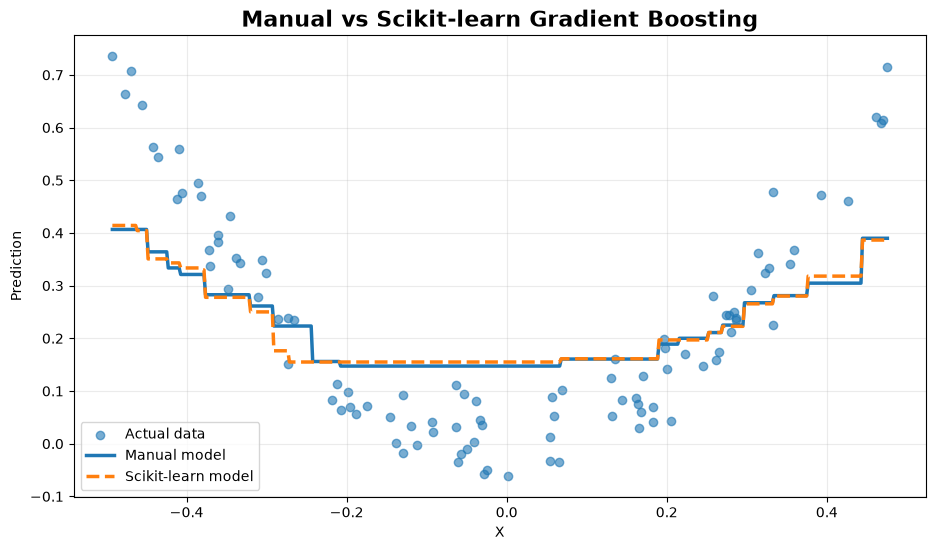

In [22]:
plt.figure(figsize=(11, 6))

plt.scatter(X[:, 0], y, alpha=0.6, label="Actual data")
plt.plot(
    X_test[:, 0],
    manual_test_curve,
    linewidth=2.5,
    label="Manual model"
)
plt.plot(
    X_test[:, 0],
    sklearn_curve,
    linestyle="--",
    linewidth=2.5,
    label="Scikit-learn model"
)

plt.title("Manual vs Scikit-learn Gradient Boosting", fontsize=16, fontweight="bold")
plt.xlabel("X")
plt.ylabel("Prediction")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [23]:
learning_rates = [0.01, 0.05, 0.1, 0.2]

results = []

for lr in learning_rates:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_leaf_nodes=8,
        random_state=RANDOM_STATE
    )
    model.fit(X, y)
    pred = model.predict(X)

    results.append({
        "Learning Rate": lr,
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R²": r2_score(y, pred)
    })

learning_rate_results = pd.DataFrame(results)
learning_rate_results


,Learning Rate,RMSE,R²
0,0.0100,0.0898,0.8094
1,0.0500,0.0318,0.9761
2,0.1000,0.0201,0.9905
3,0.2000,0.0091,0.9980


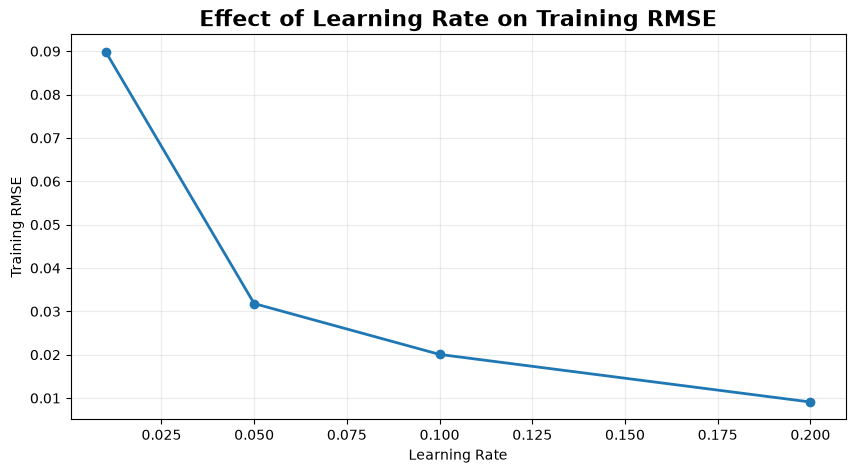

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    learning_rate_results["Learning Rate"],
    learning_rate_results["RMSE"],
    marker="o",
    linewidth=2
)

plt.title("Effect of Learning Rate on Training RMSE", fontsize=16, fontweight="bold")
plt.xlabel("Learning Rate")
plt.ylabel("Training RMSE")
plt.grid(alpha=0.25)
plt.show()

In [25]:
estimator_values = [1, 5, 10, 25, 50, 100, 200]

estimator_results = []

for n_estimators in estimator_values:
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=0.1,
        max_leaf_nodes=8,
        random_state=RANDOM_STATE
    )
    model.fit(X, y)
    pred = model.predict(X)

    estimator_results.append({
        "Estimators": n_estimators,
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R²": r2_score(y, pred)
    })

estimator_results = pd.DataFrame(estimator_results)
estimator_results

,Estimators,RMSE,R²
0,1,0.1871,0.1725
1,5,0.1309,0.5950
2,10,0.0861,0.8248
3,25,0.0427,0.9569
4,50,0.0319,0.9759
5,100,0.0201,0.9905
6,200,0.0099,0.9977


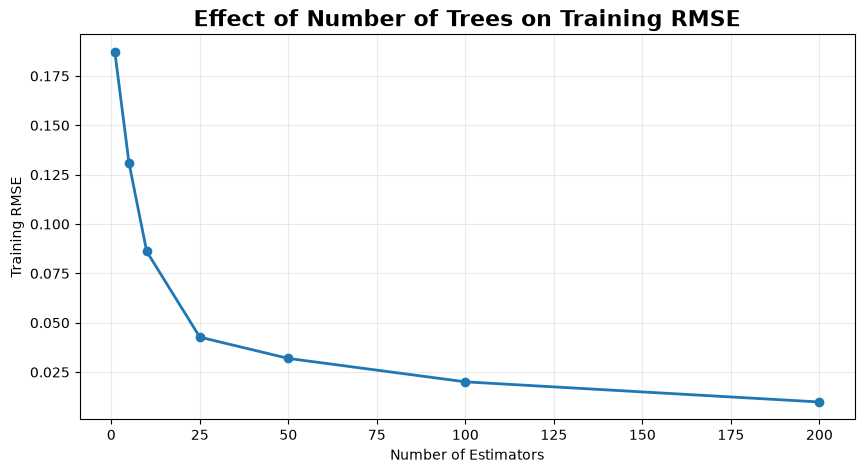

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    estimator_results["Estimators"],
    estimator_results["RMSE"],
    marker="o",
    linewidth=2
)

plt.title("Effect of Number of Trees on Training RMSE", fontsize=16, fontweight="bold")
plt.xlabel("Number of Estimators")
plt.ylabel("Training RMSE")
plt.grid(alpha=0.25)
plt.show()

In [27]:
print("Notebook completed successfully.")
print(f"Manual model trees: {len(manual_model['trees'])}")
print(f"Scikit-learn trees: {sklearn_model.n_estimators}")
print(f"Manual training RMSE: {np.sqrt(mean_squared_error(y, manual_train_pred)):.6f}")
print(f"Scikit-learn training RMSE: {np.sqrt(mean_squared_error(y, sklearn_train_pred)):.6f}")

Notebook completed successfully.
Manual model trees: 5
Scikit-learn trees: 5
Manual training RMSE: 0.128500
Scikit-learn training RMSE: 0.130937
